# Covariance Ellipse - Derivation for the Three Walking-Force Conditions

Covariance-ellipse construction for the measured handle-force point clouds, same steps
applied to all three walking conditions:

1. Constant velocity, $v = 0.2$ m/s
2. Admittance, $d_v = 20$, $d_w = 10$
3. Admittance, $d_v = 200$, $d_w = 100$

Pipeline: $(F_x, F_z)$ samples -> mean $\bar{\mathbf{F}}$ -> sample covariance $S$
(unbiased, $N-1$) -> eigendecomposition of $S$ -> ellipse at fixed scale $r = 2$ standard
deviations -> nominal coverage under a bivariate-normal assumption -> empirical coverage via
Mahalanobis distance -> ellipse overlaid on the raw scatter.

**$r$ is a number of standard deviations, not a probability.** The eigendecomposition gives
two principal axes; the SD of the data *along* those axes is $\sqrt{\lambda_1}$ (long axis)
and $\sqrt{\lambda_2}$ (short axis), and the ellipse semi-axes are $r\sqrt{\lambda_1}$,
$r\sqrt{\lambda_2}$. With $r=2$ that's a 2-sigma ellipse. The chi-square bit in Section 7
just translates that $r$ into a coverage percentage, it isn't part of the construction itself.

Scope: covariance ellipse only, doesn't touch the stability margin $M$ or any MATLAB file.

Data treatment matches `interaction_forces_analysis.ipynb` exactly: raw kgf converted to N
via $\times g$, both supports summed, thesis sign convention $F_x = -(F_{y,\text{left}} +
F_{y,\text{right}})\,g$, $F_z = (F_{z,\text{left}} + F_{z,\text{right}})\,g$. Same
unfiltered point cloud as that notebook's raw $F_x$-$F_z$ plot, nothing extra applied here.

No LaTeX export, no print styling, plain matplotlib + pandas throughout, per project convention.


## A note on reading "2 sigma" in 2-D

In 1-D, "2 sigma" is about 95%. Here it's not: a 2-sigma ellipse only encloses
$1 - e^{-2} \approx 86.5\%$ of a bivariate normal, because a point has to be close to the
mean in *both* directions at once. Formula is $\text{fraction} = 1 - e^{-r^2/2}$, see Section
7 for the full table. Section 8 also just counts how many real points actually land inside
the ellipse, since we don't really want to lean on the normality assumption too hard - that
counted number is the one to quote next to "2 standard deviations", not the theoretical one.


## Section 1 - Load the treated $(F_x, F_z)$ samples, per condition

Same loader logic as `load_condition` in `interaction_forces_analysis.ipynb`: same data
folder, same files, same `g = 9.81`, same kgf->N conversion and sign convention. Only
`Fx_thesis_N` and `Fz_total_N` are kept here, stacked into an $N \times 2$ array `XY` per
condition, columns $[F_x, F_z]$.

Counts below are force samples only (velocity files aren't used in this notebook).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

g = 9.81  # m/s^2, matches interaction_forces_analysis.ipynb / rollator_dynamics.m

# same axis window on every Fx-Fz plot below so a 1 N step looks the same everywhere
# and plots stay comparable across sections / re-runs
FX_LIM = (-200.0, 200.0)   # N
FZ_LIM = (-50.0, 350.0)    # N

DATA_DIR = Path("Interaction Force Measured Data")  # same subfolder as interaction_forces_analysis.ipynb

CONDITIONS = {
    1: {
        "label": "Condition 1: constant velocity 0.2 m/s",
        "short": "Const. vel.",
        "thesis_name": "Constant velocity, v = 0.2 m/s",
        "force_file": "walker_straight_1_constvel-0.2ms_force.csv",
    },
    2: {
        "label": "Condition 2: admittance, dv=20, dw=10",
        "short": "Adm. dv=20",
        "thesis_name": "Admittance, dv = 20, dw = 10",
        "force_file": "walker_straight_2_adm-dv20-dw10_force.csv",
    },
    3: {
        "label": "Condition 3: admittance, dv=200, dw=100",
        "short": "Adm. dv=200",
        "thesis_name": "Admittance, dv = 200, dw = 100",
        "force_file": "walker_straight_3_adm-dv200-dw100_force.csv",
    },
}


def load_treated_forces(cond):
    # same treatment as load_condition() in interaction_forces_analysis.ipynb:
    # kgf -> N (x g), both supports summed, thesis sign convention, no filtering
    force = pd.read_csv(DATA_DIR / cond["force_file"])
    Fz_total_N = (force["Fz_left"] + force["Fz_right"]) * g
    Fx_thesis_N = -(force["Fy_left"] + force["Fy_right"]) * g
    return np.column_stack([Fx_thesis_N.to_numpy(), Fz_total_N.to_numpy()])  # columns: [Fx, Fz]


data = {}
for cid, cond in CONDITIONS.items():
    XY = load_treated_forces(cond)
    data[cid] = {**cond, "XY": XY}

counts_df = pd.DataFrame(
    [{"condition": data[cid]["short"], "n_samples": len(data[cid]["XY"])} for cid in CONDITIONS]
).set_index("condition")
counts_df


,n_samples
condition,
Const. vel.,15410
Adm. dv=20,9534
Adm. dv=200,17579


## Section 2 - Raw point cloud per condition

$F_x$ vs $F_z$, one scatter per condition, before any ellipse. Equal aspect ratio and the
shared `FX_LIM` / `FZ_LIM` window from Section 1 so a 1 N step is the same length everywhere.


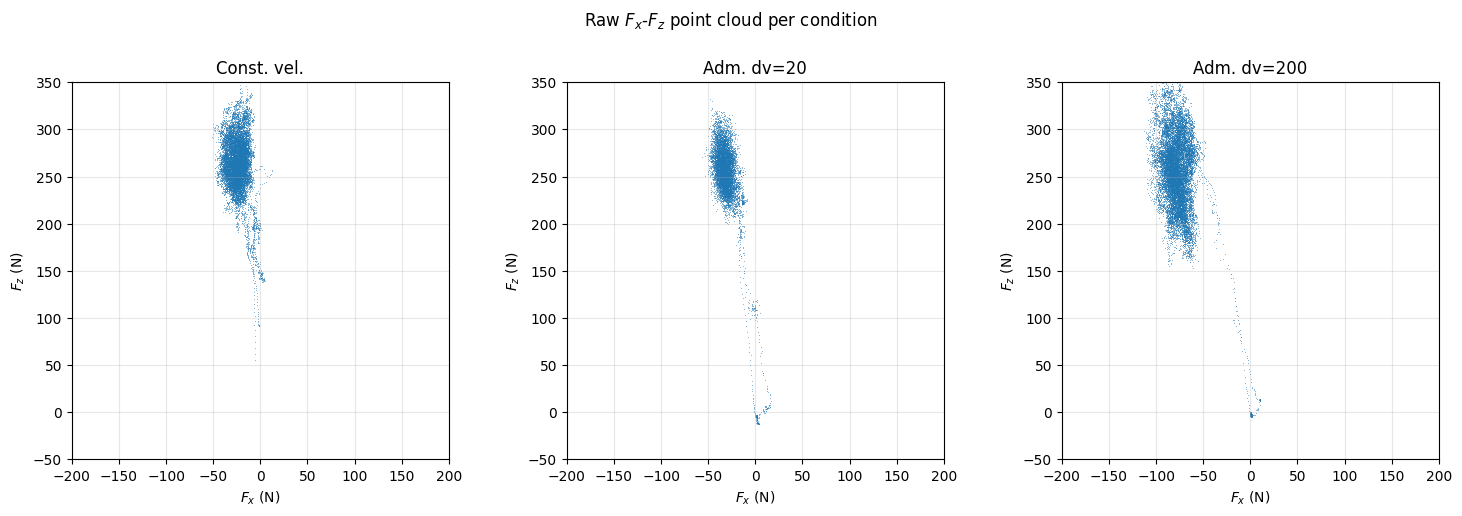

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cid in zip(axes, CONDITIONS):
    XY = data[cid]["XY"]
    ax.scatter(XY[:, 0], XY[:, 1], s=2, alpha=0.4, marker=".", linewidths=0, rasterized=True)
    ax.set_xlabel(r"$F_x$ (N)")
    ax.set_ylabel(r"$F_z$ (N)")
    ax.set_title(data[cid]["short"])
    ax.set_aspect("equal")
    ax.set_xlim(*FX_LIM)
    ax.set_ylim(*FZ_LIM)
    ax.grid(True, alpha=0.3)

fig.suptitle("Raw $F_x$-$F_z$ point cloud per condition")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Section 3 - Sample mean $\bar{\mathbf{F}} = (\bar{F}_x, \bar{F}_z)$

Plain column mean, per condition.


In [3]:
for cid in CONDITIONS:
    XY = data[cid]["XY"]
    data[cid]["mu"] = XY.mean(axis=0)  # [Fx_bar, Fz_bar]

mean_df = pd.DataFrame(
    [
        {
            "condition": data[cid]["short"],
            "Fx_bar_N": data[cid]["mu"][0],
            "Fz_bar_N": data[cid]["mu"][1],
        }
        for cid in CONDITIONS
    ]
).set_index("condition")
mean_df

,Fx_bar_N,Fz_bar_N
condition,,
Const. vel.,-24.257588,262.349885
Adm. dv=20,-31.358106,250.781484
Adm. dv=200,-77.619713,253.171643


## Section 4 - Sample covariance matrix $S$

$$S = \frac{1}{N-1} \sum_{i=1}^{N} (\mathbf{F}_i - \bar{\mathbf{F}})(\mathbf{F}_i - \bar{\mathbf{F}})^\top,$$

via `np.cov(XY.T, ddof=1)`. Reported as $S_{xx}$, $S_{zz}$, $S_{xz}$ (symmetric, so $S_{zx} = S_{xz}$).


In [4]:
for cid in CONDITIONS:
    XY = data[cid]["XY"]
    S = np.cov(XY.T, ddof=1)  # 2x2, unbiased N-1 estimator
    data[cid]["S"] = S

cov_df = pd.DataFrame(
    [
        {
            "condition": data[cid]["short"],
            "S_xx": data[cid]["S"][0, 0],
            "S_zz": data[cid]["S"][1, 1],
            "S_xz": data[cid]["S"][0, 1],
        }
        for cid in CONDITIONS
    ]
).set_index("condition")
cov_df

,S_xx,S_zz,S_xz
condition,,,
Const. vel.,67.371816,803.626061,-52.009031
Adm. dv=20,80.537657,2055.333839,-293.778392
Adm. dv=200,172.611233,1964.686599,-295.133668


## Section 5 - Eigendecomposition of $S$

`np.linalg.eigh` rather than `eig` since $S$ is symmetric - gives real eigenvalues and an
orthonormal eigenvector matrix directly. Eigenvalues come back ascending, reordered here to
descending so $\lambda_1 \geq \lambda_2$ ($\lambda_1$ = major-axis variance). Columns of
$V$ are the matching unit eigenvectors, $V[:,0]$ major axis, $V[:,1]$ minor axis.

$\sigma_1 = \sqrt{\lambda_1}$, $\sigma_2 = \sqrt{\lambda_2}$ printed too - these are what
the ellipse scale $r$ actually multiplies in Section 6.


In [5]:
for cid in CONDITIONS:
    S = data[cid]["S"]
    evals, evecs = np.linalg.eigh(S)          # ascending eigenvalues, orthonormal evecs
    order = np.argsort(evals)[::-1]           # -> descending: lambda1 >= lambda2
    evals = evals[order]
    evecs = evecs[:, order]
    data[cid]["lambda"] = evals              # [lambda1, lambda2]
    data[cid]["V"] = evecs                   # columns: [major axis, minor axis]
    data[cid]["sigma"] = np.sqrt(evals)      # [sigma1, sigma2] = SD along each principal axis

    print(f"{data[cid]['short']}")
    print(f"  lambda1 = {evals[0]:.4f} N^2   lambda2 = {evals[1]:.4f} N^2")
    print(f"  sigma1  = sqrt(lambda1) = {np.sqrt(evals[0]):.4f} N   "
          f"sigma2 = sqrt(lambda2) = {np.sqrt(evals[1]):.4f} N   "
          f"(SD along major / minor axis)")
    print(f"  V (columns = major, minor axis):")
    print(f"    [{evecs[0,0]: .6f}  {evecs[0,1]: .6f}]")
    print(f"    [{evecs[1,0]: .6f}  {evecs[1,1]: .6f}]")
    ang = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))
    print(f"  major-axis angle from +Fx: {ang:.2f} deg")
    print()

eig_df = pd.DataFrame(
    [
        {
            "condition": data[cid]["short"],
            "lambda1": data[cid]["lambda"][0],
            "lambda2": data[cid]["lambda"][1],
            "sigma1_N": data[cid]["sigma"][0],
            "sigma2_N": data[cid]["sigma"][1],
            "v1_Fx": data[cid]["V"][0, 0],
            "v1_Fz": data[cid]["V"][1, 0],
            "v2_Fx": data[cid]["V"][0, 1],
            "v2_Fz": data[cid]["V"][1, 1],
        }
        for cid in CONDITIONS
    ]
).set_index("condition")
eig_df

Const. vel.
  lambda1 = 807.2818 N^2   lambda2 = 63.7160 N^2
  sigma1  = sqrt(lambda1) = 28.4127 N   sigma2 = sqrt(lambda2) = 7.9822 N   (SD along major / minor axis)
  V (columns = major, minor axis):
    [-0.070118  -0.997539]
    [ 0.997539  -0.070118]
  major-axis angle from +Fx: 94.02 deg

Adm. dv=20
  lambda1 = 2098.1108 N^2   lambda2 = 37.7606 N^2
  sigma1  = sqrt(lambda1) = 45.8051 N   sigma2 = sqrt(lambda2) = 6.1450 N   (SD along major / minor axis)
  V (columns = major, minor axis):
    [-0.144090  -0.989565]
    [ 0.989565  -0.144090]
  major-axis angle from +Fx: 98.28 deg

Adm. dv=200
  lambda1 = 2012.0404 N^2   lambda2 = 125.2575 N^2
  sigma1  = sqrt(lambda1) = 44.8558 N   sigma2 = sqrt(lambda2) = 11.1918 N   (SD along major / minor axis)
  V (columns = major, minor axis):
    [-0.158422  -0.987371]
    [ 0.987371  -0.158422]
  major-axis angle from +Fx: 99.12 deg



,lambda1,lambda2,sigma1_N,sigma2_N,v1_Fx,v1_Fz,v2_Fx,v2_Fz
condition,,,,,,,,
Const. vel.,807.281829,63.716048,28.412705,7.982233,-0.070118,0.997539,-0.997539,-0.070118
Adm. dv=20,2098.110847,37.760650,45.805140,6.144969,-0.144090,0.989565,-0.989565,-0.144090
Adm. dv=200,2012.040357,125.257474,44.855773,11.191849,-0.158422,0.987371,-0.987371,-0.158422


## Section 6 - Ellipse construction at $r = 2$ standard deviations

Ellipse built at a fixed number of standard deviations, `R_SCALE`, set once below - not from
a chi-square percentile lookup. Change `R_SCALE` and everything downstream (semi-axes,
coverage numbers, overlay) follows automatically.

$$a = r\sigma_1 = r\sqrt{\lambda_1}, \qquad b = r\sigma_2 = r\sqrt{\lambda_2},$$
$$\mathbf{p}(t) = \boldsymbol{\mu} + r\, V\, D^{1/2}
\begin{bmatrix}\cos t\\ \sin t\end{bmatrix}, \qquad t \in [0, 2\pi].$$

$a$ = semi-major axis (along $V[:,0]$), $b$ = semi-minor axis (along $V[:,1]$). Table below
puts $\sigma_1, \sigma_2$ next to $a, b$ so the factor of $r$ is visible.


In [6]:
R_SCALE = 2.0  # ellipse scale in standard deviations along each principal axis (r = 2 -> 2-sigma)

t = np.linspace(0.0, 2.0 * np.pi, 400)
unit_circle = np.vstack([np.cos(t), np.sin(t)])  # 2 x 400

for cid in CONDITIONS:
    mu = data[cid]["mu"]
    lam = data[cid]["lambda"]
    V = data[cid]["V"]

    a = R_SCALE * np.sqrt(lam[0])  # semi-major axis
    b = R_SCALE * np.sqrt(lam[1])  # semi-minor axis
    D_half = np.diag(np.sqrt(lam))

    # p(t) = mu + r * V @ sqrt(D) @ [cos t, sin t]
    ellipse = mu[:, None] + R_SCALE * (V @ D_half @ unit_circle)  # 2 x 400

    data[cid]["a"] = a
    data[cid]["b"] = b
    data[cid]["ellipse"] = ellipse

axis_df = pd.DataFrame(
    [
        {
            "condition": data[cid]["short"],
            "sigma1_N": data[cid]["sigma"][0],
            "sigma2_N": data[cid]["sigma"][1],
            "r": R_SCALE,
            "a_semi_major_N": data[cid]["a"],   # = r * sigma1
            "b_semi_minor_N": data[cid]["b"],   # = r * sigma2
        }
        for cid in CONDITIONS
    ]
).set_index("condition")
axis_df

,sigma1_N,sigma2_N,r,a_semi_major_N,b_semi_minor_N
condition,,,,,
Const. vel.,28.412705,7.982233,2.0,56.825411,15.964467
Adm. dv=20,45.805140,6.144969,2.0,91.610280,12.289939
Adm. dv=200,44.855773,11.191849,2.0,89.711546,22.383697


## Section 7 - Nominal coverage implied by $r$

Translates the chosen $r$ into a percentage. Under a bivariate-normal assumption, squared
Mahalanobis distance follows a $\chi^2_2$ distribution, CDF $F(s) = 1 - e^{-s/2}$. A point is
inside the $r$-ellipse when its Mahalanobis distance is $\leq r$, so

$$\text{nominal coverage} = 1 - e^{-r^2/2}.$$

Evaluated at the current `R_SCALE`, not hard-coded - for $r=2$ that's $\approx 0.8647$. Same
for all three conditions (depends only on $r$), shown per-condition so the table is
self-contained.

Reference table below: 2-D enclosed fraction vs the 1-D two-sided fraction
$\operatorname{erf}(r/\sqrt{2})$ for a few values of $r$, and the inverse - what $r$ would be
needed to hit some target coverage ($r = \sqrt{-2\ln(1-p)}$).


In [7]:
from math import erf

nominal_coverage = 1.0 - np.exp(-(R_SCALE ** 2) / 2.0)
print(f"R_SCALE = {R_SCALE} standard deviations")
print(f"nominal coverage (2-D) = 1 - exp(-r^2/2) = {nominal_coverage:.6f}  ({100*nominal_coverage:.2f}%)")

for cid in CONDITIONS:
    data[cid]["nominal_coverage"] = nominal_coverage

nominal_df = pd.DataFrame(
    [
        {
            "condition": data[cid]["short"],
            "r_sigma": R_SCALE,
            "nominal_coverage": data[cid]["nominal_coverage"],
            "nominal_%": 100.0 * data[cid]["nominal_coverage"],
        }
        for cid in CONDITIONS
    ]
).set_index("condition")
print()
print(nominal_df)

# reference table: r (sigmas) vs enclosed fraction, 2-D ellipse vs 1-D interval
r_grid = [1.0, 1.5, 2.0, 2.5, 3.0]
ref_r = pd.DataFrame(
    [
        {
            "r_sigma": r,
            "ellipse_2D_%": 100.0 * (1.0 - np.exp(-r ** 2 / 2.0)),
            "interval_1D_%": 100.0 * erf(r / np.sqrt(2.0)),
        }
        for r in r_grid
    ]
).set_index("r_sigma")

# inverse: r needed for a target 2-D coverage p
targets = [0.50, 0.80, 0.90, 0.95, 0.99]
ref_target = pd.DataFrame(
    [{"target_coverage_%": 100.0 * p, "r_sigma_needed": np.sqrt(-2.0 * np.log(1.0 - p))} for p in targets]
).set_index("target_coverage_%")

print("\nReference — r in standard deviations vs enclosed fraction:")
print(ref_r.round(2))
print("\nReference — r needed to hit a target 2-D coverage:")
print(ref_target.round(3))

R_SCALE = 2.0 standard deviations
nominal coverage (2-D) = 1 - exp(-r^2/2) = 0.864665  (86.47%)

             r_sigma  nominal_coverage  nominal_%
condition                                        
Const. vel.      2.0          0.864665  86.466472
Adm. dv=20       2.0          0.864665  86.466472
Adm. dv=200      2.0          0.864665  86.466472

Reference — r in standard deviations vs enclosed fraction:
         ellipse_2D_%  interval_1D_%
r_sigma                             
1.0             39.35          68.27
1.5             67.53          86.64
2.0             86.47          95.45
2.5             95.61          98.76
3.0             98.89          99.73

Reference — r needed to hit a target 2-D coverage:
                   r_sigma_needed
target_coverage_%                
50.0                        1.177
80.0                        1.794
90.0                        2.146
95.0                        2.448
99.0                        3.035


## Section 8 - Empirical coverage via Mahalanobis distance

$$d_i = \sqrt{(\mathbf{F}_i - \boldsymbol{\mu})^\top S^{-1} (\mathbf{F}_i - \boldsymbol{\mu})}.$$

Empirical coverage = fraction of samples with $d_i \leq r$, i.e. exactly the samples that
land inside the Section 6 ellipse. Compared against the Section 7 nominal value - the gap
between them is a measure of how non-Gaussian the point cloud actually is at this radius.
This empirical number, not the nominal one, is what gets quoted alongside "2 standard
deviations" in the thesis text.


In [8]:
for cid in CONDITIONS:
    XY = data[cid]["XY"]
    mu = data[cid]["mu"]
    S = data[cid]["S"]

    diff = XY - mu
    Sinv = np.linalg.inv(S)
    d2 = np.einsum("ij,jk,ik->i", diff, Sinv, diff)  # squared Mahalanobis distance per sample
    d = np.sqrt(d2)

    inside = d <= R_SCALE
    data[cid]["empirical_coverage"] = inside.mean()
    data[cid]["n_inside"] = int(inside.sum())

coverage_df = pd.DataFrame(
    [
        {
            "condition": data[cid]["short"],
            "n_samples": len(data[cid]["XY"]),
            "n_inside": data[cid]["n_inside"],
            "nominal_%": 100.0 * data[cid]["nominal_coverage"],
            "empirical_%": 100.0 * data[cid]["empirical_coverage"],
        }
        for cid in CONDITIONS
    ]
).set_index("condition")
coverage_df

,n_samples,n_inside,nominal_%,empirical_%
condition,,,,
Const. vel.,15410,13588,86.466472,88.176509
Adm. dv=20,9534,8709,86.466472,91.346759
Adm. dv=200,17579,16105,86.466472,91.614995


### Table 1.8 - Nominal vs. empirical coverage of the fixed 2s ellipse

Built directly from `coverage_df` above: nominal coverage is $1 - e^{-r^2/2}$ at $r=2$ (same
for all three conditions), empirical is the counted fraction inside the ellipse. One decimal
place, matches the thesis table formatting.


In [9]:
assert R_SCALE == 2.0, "Table 1.8 is defined for the fixed 2-sigma ellipse (R_SCALE = 2)"

table_1_8 = pd.DataFrame(
    [
        {
            "Condition": CONDITIONS[cid]["thesis_name"],
            "Nominal coverage (%)": round(100.0 * data[cid]["nominal_coverage"], 1),
            "Empirical coverage (%)": round(100.0 * data[cid]["empirical_coverage"], 1),
        }
        for cid in CONDITIONS
    ]
).set_index("Condition")

print("Table 1.8: Nominal vs. empirical coverage of the fixed 2-sigma ellipse.")
print(table_1_8.to_string())
table_1_8

Table 1.8: Nominal vs. empirical coverage of the fixed 2-sigma ellipse.
                                Nominal coverage (%)  Empirical coverage (%)
Condition                                                                   
Constant velocity, v = 0.2 m/s                  86.5                    88.2
Admittance, dv = 20, dw = 10                    86.5                    91.3
Admittance, dv = 200, dw = 100                  86.5                    91.6


,Nominal coverage (%),Empirical coverage (%)
Condition,,
"Constant velocity, v = 0.2 m/s",86.5,88.2
"Admittance, dv = 20, dw = 10",86.5,91.3
"Admittance, dv = 200, dw = 100",86.5,91.6


## Section 9 - All conditions with their 2s ellipses on one axes

Three point clouds plus their fixed 2-sigma ellipses (Section 6), one colour per condition,
mean marked with an x. Equal aspect ratio, fixed axis limits, so shapes stay faithful and
comparable across re-runs. This is Figure 1.4 in the thesis: walking-force samples with the
fixed 2-sigma covariance ellipse overlaid, per condition.


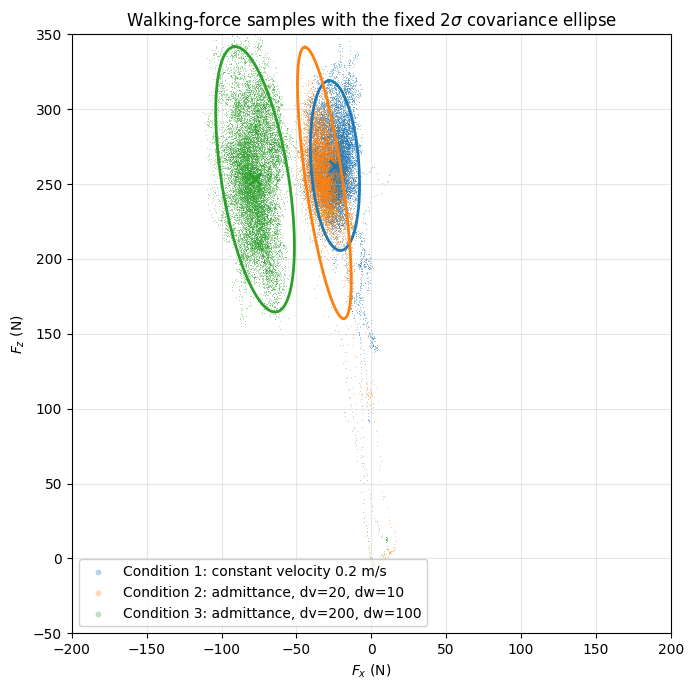

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for cid, color in zip(CONDITIONS, colors):
    XY = data[cid]["XY"]
    mu = data[cid]["mu"]
    ell = data[cid]["ellipse"]

    ax.scatter(XY[:, 0], XY[:, 1], s=2, alpha=0.30, marker=".", linewidths=0,
               color=color, rasterized=True, label=data[cid]["label"])
    ax.plot(ell[0], ell[1], color=color, lw=2)
    ax.plot(mu[0], mu[1], "x", color=color, ms=9, mew=2)

ax.set_xlabel(r"$F_x$ (N)")
ax.set_ylabel(r"$F_z$ (N)")
ax.set_title(f"Walking-force samples with the fixed {R_SCALE:g}$\\sigma$ covariance ellipse")
ax.set_aspect("equal")
ax.set_xlim(*FX_LIM)
ax.set_ylim(*FZ_LIM)
ax.grid(True, alpha=0.3)
ax.legend(markerscale=6, loc="lower left", framealpha=0.9)
fig.tight_layout()
plt.show()

## Summary tables

For pulling into the thesis: mean, covariance entries, nominal vs empirical coverage.


In [11]:
print("Sample counts:")
print(counts_df)
print("\nSample mean (N):")
print(mean_df)
print("\nSample covariance entries (N^2):")
print(cov_df)
print("\nEigenvalues / eigenvectors / principal-axis SDs:")
print(eig_df)
print(f"\nEllipse semi-axes (N) at r = {R_SCALE} standard deviations (a = r*sigma1, b = r*sigma2):")
print(axis_df)
print("\nCoverage: nominal (2-D Gaussian) vs empirical (counted)")
print(coverage_df)

print(
    f"\nIn words: the ellipse is drawn at r = {R_SCALE:g} standard deviations along each "
    f"principal axis.\nA 2-D {R_SCALE:g}-sigma ellipse nominally encloses "
    f"{100*nominal_coverage:.1f}% of a bivariate normal; empirically it contains"
)
for cid in CONDITIONS:
    print(f"  {data[cid]['short']:<12} {100*data[cid]['empirical_coverage']:.1f}% of samples")

Sample counts:
             n_samples
condition             
Const. vel.      15410
Adm. dv=20        9534
Adm. dv=200      17579

Sample mean (N):
              Fx_bar_N    Fz_bar_N
condition                         
Const. vel. -24.257588  262.349885
Adm. dv=20  -31.358106  250.781484
Adm. dv=200 -77.619713  253.171643

Sample covariance entries (N^2):
                   S_xx         S_zz        S_xz
condition                                       
Const. vel.   67.371816   803.626061  -52.009031
Adm. dv=20    80.537657  2055.333839 -293.778392
Adm. dv=200  172.611233  1964.686599 -295.133668

Eigenvalues / eigenvectors / principal-axis SDs:
                 lambda1     lambda2   sigma1_N   sigma2_N     v1_Fx  \
condition                                                              
Const. vel.   807.281829   63.716048  28.412705   7.982233 -0.070118   
Adm. dv=20   2098.110847   37.760650  45.805140   6.144969 -0.144090   
Adm. dv=200  2012.040357  125.257474  44.855773  11.191849 -